# PTB-XL ECG Dataset - Data Exploration & EDA

**Course:** AAI-501 - Introduction to AI and Machine Learning  
**Project:** ECG Arrhythmia Classification  
**Part:** 1 - Data Preparation & EDA  
**Author:** Ashok Bhairwal

## Objectives
1. Load and understand the PTB-XL dataset structure
2. Explore metadata and patient demographics
3. Analyze diagnostic label distribution
4. Visualize sample ECG signals
5. Identify data quality issues

In [82]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset

In [83]:
# Define paths
DATA_PATH = Path('../data/raw/physionet.org/files/ptb-xl/1.0.3')
SAMPLING_RATE = 100  # Use 100 Hz for faster processing
# Save enhanced metadata
OUTPUT_PATH = Path('../data/preprocessed')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Load metadata
df = pd.read_csv(DATA_PATH / 'ptbxl_database.csv', index_col='ecg_id')
print(f"Dataset shape: {df.shape}")
print(f"Total ECG records: {len(df)}")
print(f"Total patients: {df['patient_id'].nunique()}")
df.head()

Dataset shape: (21799, 27)
Total ECG records: 21799
Total patients: 18869


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [84]:
# Column names and descriptions
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. patient_id
 2. age
 3. sex
 4. height
 5. weight
 6. nurse
 7. site
 8. device
 9. recording_date
10. report
11. scp_codes
12. heart_axis
13. infarction_stadium1
14. infarction_stadium2
15. validated_by
16. second_opinion
17. initial_autogenerated_report
18. validated_by_human
19. baseline_drift
20. static_noise
21. burst_noise
22. electrodes_problems
23. extra_beats
24. pacemaker
25. strat_fold
26. filename_lr
27. filename_hr


In [85]:
selected_columns = [
    "patient_id", "age", "sex", "height", "weight", "nurse", "site",
    "device", "recording_date", "report", "scp_codes", "heart_axis",
    "infarction_stadium1", "infarction_stadium2", "validated_by",
    "second_opinion", "initial_autogenerated_report", "validated_by_human",
    "baseline_drift", "static_noise", "burst_noise",
    "electrodes_problems", "extra_beats", "pacemaker",
    "strat_fold", "filename_lr", "filename_hr"
]

# Only select columns that actually exist in the dataframe
existing_cols = [col for col in selected_columns if col in df.columns]
missing_cols = [col for col in selected_columns if col not in df.columns]
df_metadata = df[existing_cols].copy()
if missing_cols:
    print(f"Note: The following columns don't exist yet and will be skipped: {missing_cols}")
    print(f"      These will be added after diagnostic labels are created in Section 3")
else :
    print(f"No missing columns found in the dataset as Shape is {df_metadata.shape}")


No missing columns found in the dataset as Shape is (21799, 27)


## 2.  Data Cleaning

#### 2a. Identifying and Removing Missing Data

This step removes ECG records for patients whose required ECG files (.dat and .hea) are missing.

In [86]:
# Check for missing files AND filter dataset
missing_dat = []
missing_hea = []
missing_both = []
valid_records = []
print("="*70)
# Check each record
for ecg_id, row in df.iterrows():
    # FIX: don't hard-cast patient_id to int here. If patient_id is ever missing
    # (NaN), int(nan) raises ValueError and crashes this loop before we even get
    # a chance to handle missing-core-identifier rows in the next section. Keep
    # patient_id as-is; it's only used for reporting in this cell.
    patient_id = row['patient_id']
    filename_lr = row['filename_lr']

    # Construct file paths
    base_path = DATA_PATH / filename_lr
    dat_file = Path(str(base_path) + '.dat')
    hea_file = Path(str(base_path) + '.hea')

    # Check existence
    dat_exists = dat_file.exists()
    hea_exists = hea_file.exists()

    # Categorize
    if not dat_exists and not hea_exists:
        missing_both.append((ecg_id, patient_id))
    elif not dat_exists:
        missing_dat.append((ecg_id, patient_id))
    elif not hea_exists:
        missing_hea.append((ecg_id, patient_id))
    else:
        valid_records.append(ecg_id)

# Get unique patient IDs with any missing file
all_missing_patients = set()
for ecg_id, patient_id in missing_dat + missing_hea + missing_both:
    all_missing_patients.add(patient_id)
all_missing_patients = sorted(list(all_missing_patients))

# Print summary
print(f"RESULTS:")
print("="*70)
print(f"Total records checked:      {len(df):,}")
print(f"Valid records (both files): {len(valid_records):,}")
print(f"Missing .dat only:          {len(missing_dat)} records")
print(f"Missing .hea only:          {len(missing_hea)} records")
print(f"Missing both files:         {len(missing_both)} records")
print(f"Total records to remove:    {len(missing_dat) + len(missing_hea) + len(missing_both)}")
print(f"Unique patient IDs affected: {len(all_missing_patients)}")


# FILTER DATASET - Remove records with missing files
print("\n" + "="*70)
print("FILTERING DATASET")
print("="*70)

df_original = df.copy()
original_count = len(df)

# Keep only valid records
df = df.loc[valid_records]

removed_count = original_count - len(df)

print(f"\nFiltered Dataset shape: {df.shape}")


RESULTS:
Total records checked:      21,799
Valid records (both files): 21,762
Missing .dat only:          19 records
Missing .hea only:          18 records
Missing both files:         0 records
Total records to remove:    37
Unique patient IDs affected: 37

FILTERING DATASET

Filtered Dataset shape: (21762, 27)


-------------
#### 2b. Remove Records with Missing Core Identifiers

**Core identifiers** are essential columns that must have values for a record to be valid:
- `patient_id` - Patient identifier
- `scp_codes` - Diagnostic codes (cannot be empty)

Records with missing values in any of these columns will be removed.

In [87]:
# Define core identifiers - these MUST have values
core_identifiers = ['patient_id', 'scp_codes']  # ecg_id is the index

initial_count = len(df)
print(f"Initial record count: {initial_count:,}")

# Check each core identifier
print("Checking core identifiers:")
print("-"*70)

records_to_remove = set()

# Check patient_id
if 'patient_id' in df.columns:
    missing_patient_id = df[df['patient_id'].isna()].index.tolist()
    if missing_patient_id:
        print(f"  patient_id - Missing: {len(missing_patient_id)} records")
        records_to_remove.update(missing_patient_id)
    else:
        print(f"  patient_id - OK: All records have patient_id")
else:
    print(f"  patient_id - WARNING: Column not found")

# Check scp_codes
if 'scp_codes' in df.columns:
    # Check for NaN or empty string
    missing_scp = df[df['scp_codes'].isna() | (df['scp_codes'].astype(str).str.strip() == '')].index.tolist()
    if missing_scp:
        print(f"  scp_codes  - Missing: {len(missing_scp)} records")
        records_to_remove.update(missing_scp)
    else:
        print(f"  scp_codes  - OK: All records have diagnostic codes")
else:
    print(f"  scp_codes  - WARNING: Column not found")

# FIX: the original notebook computed `records_to_remove` but never dropped
# them from `df` -- rows missing core identifiers were silently kept through
# the rest of the pipeline. Actually remove them here.
if records_to_remove:
    df = df.drop(index=list(records_to_remove))
    print(f"\n  -> Removed {len(records_to_remove)} record(s) missing core identifiers.")
else:
    print(f"\n  -> No records removed (all core identifiers present).")

print(f"  Records remaining: {len(df):,}")
print("" + "="*70)
print(f"OK: Core identifier validation complete")
print("="*70)


Initial record count: 21,762
Checking core identifiers:
----------------------------------------------------------------------
  patient_id - OK: All records have patient_id
  scp_codes  - OK: All records have diagnostic codes

  -> No records removed (all core identifiers present).
  Records remaining: 21,762
OK: Core identifier validation complete


#### 2c. Remove Duplicate ECG Records

PTB-XL intentionally contains **multiple ECG recordings per patient** (21,799
recordings from 18,869 patients per Wagner et al. 2020 and the anchor paper's
dataset description) -- these are separate clinical visits, not duplicates.
Collapsing to one row per patient 
is not duplicate removal: it silently discards ~15% of legitimate recordings
and shrinks the dataset well below the size the paper and this project's
README report.

**Fix:** a *true* duplicate is the same recording logged more than once --
identical `patient_id`, `recording_date`, and `scp_codes`. We only drop exact
duplicates of that kind and keep every distinct visit.


In [88]:
# Remove TRUE duplicate ECG records only (not one-per-patient collapsing)
print("" + "="*70)
print("SECTION 2c: REMOVING TRUE DUPLICATE ECG RECORDS")
print("="*70)

total_patients = df['patient_id'].nunique()
total_records = len(df)
print(f"Before duplicate check:")
print(f"  Total records:           {total_records:,}")
print(f"  Unique patients:         {total_patients:,}")
print(f"  Avg records per patient: {total_records/total_patients:.2f}")
print(f"  (Multiple records per patient are EXPECTED -- separate clinical visits,")
print(f"   not duplicates. See PTB-XL's own documentation: 21,799 recordings from")
print(f"   18,869 patients.)")

# A true duplicate = identical patient_id + recording_date + scp_codes.
# (filename_lr/filename_hr are already guaranteed unique per row since they are
# derived 1:1 from ecg_id, so they can't be used to detect true duplicates.)
dup_subset = ['patient_id', 'recording_date', 'scp_codes']

df_before_dedup = df.copy()
duplicate_mask = df.duplicated(subset=dup_subset, keep=False)
n_duplicate_rows = int(duplicate_mask.sum())

print(f"\nTrue duplicate check (same patient + timestamp + diagnosis codes):")
print(f"  Rows involved in an exact duplicate: {n_duplicate_rows}")

if n_duplicate_rows > 0:
    print(f"  Example duplicate group:")
    example_key = df.loc[duplicate_mask, dup_subset].iloc[0]
    example_group = df[
        (df['patient_id'] == example_key['patient_id']) &
        (df['recording_date'] == example_key['recording_date']) &
        (df['scp_codes'] == example_key['scp_codes'])
    ]
    print(example_group[dup_subset].to_string())

df = df.drop_duplicates(subset=dup_subset, keep='first')
records_removed = len(df_before_dedup) - len(df)

print(f"\nAfter true-duplicate removal:")
print(f"  Records remaining: {len(df):,}")
print(f"  Unique patients:   {df['patient_id'].nunique():,}")
print(f"  Records removed:   {records_removed:,}  (exact duplicates only)")
print(f"  Avg records/patient (kept, by design): {len(df)/df['patient_id'].nunique():.2f}")
print("="*70)


SECTION 2c: REMOVING TRUE DUPLICATE ECG RECORDS
Before duplicate check:
  Total records:           21,762
  Unique patients:         18,843
  Avg records per patient: 1.15
  (Multiple records per patient are EXPECTED -- separate clinical visits,
   not duplicates. See PTB-XL's own documentation: 21,799 recordings from
   18,869 patients.)

True duplicate check (same patient + timestamp + diagnosis codes):
  Rows involved in an exact duplicate: 2
  Example duplicate group:
        patient_id       recording_date                   scp_codes
ecg_id                                                             
11842      13781.0  1994-02-26 11:09:57  {'NORM': 100.0, 'SR': 0.0}
11843      13781.0  1994-02-26 11:09:57  {'NORM': 100.0, 'SR': 0.0}

After true-duplicate removal:
  Records remaining: 21,761
  Unique patients:   18,843
  Records removed:   1  (exact duplicates only)
  Avg records/patient (kept, by design): 1.15


#### 2d. Identify and Handle Outliers

Remove records with unrealistic or impossible values, and correctly handle a
PTB-XL-specific data convention:

1. **De-identified age top-coding** -- PTB-XL encodes any age over 89 as the
   literal value `300` for de-identification (confirmed directly in the raw
   PhysioNet data, e.g. patient 11810 / ecg_id 108). This is a **valid
   censored value**, not corrupted data, and must not be dropped as an
   outlier. We recode it to a documented value (90) and keep a flag column so
   this information isn't lost.
2. **Domain knowledge** -- impossible values (negative/zero age, unrealistic
   height/weight) are removed.
3. **Statistical (IQR) check** -- reported for transparency only. It is
   *not* used to drop records: real clinical age/height/weight distributions
   are wide, and dropping statistically-unusual-but-medically-plausible
   patients would bias the dataset (e.g. against elderly or pediatric
   patients) without a clinical justification.


In [89]:
# Identify and handle outliers
print("="*70)
print("IDENTIFYING AND HANDLING OUTLIERS")
print("="*70)

df_before_outliers = df.copy()
initial_count = len(df)
outlier_records = set()

# 0. PTB-XL DE-IDENTIFICATION TOP-CODE: age == 300 means "age > 89"
print("0. PTB-XL De-identification Top-Code Handling:")
print("-"*70)
age_deidentified_mask = (df['age'] == 300)
n_deidentified = int(age_deidentified_mask.sum())
print(f"  Records with age==300 (PTB-XL code for '>89 years'): {n_deidentified}")

df['age_over_89'] = age_deidentified_mask.astype(int)
if n_deidentified > 0:
    # Recode to a documented, plausible value instead of dropping/leaving as 300.
    df.loc[age_deidentified_mask, 'age'] = 90
    print(f"  -> Recoded these {n_deidentified} record(s) from 300 to 90 and flagged")
    print(f"     them in a new 'age_over_89' column (kept, not removed).")
else:
    print(f"  -> None found in this slice of the data.")

# 1. DOMAIN-BASED OUTLIERS (clinically impossible values only)
print("1. Domain-Based Outlier Detection:")
print("-"*70)

# Age outliers -- upper bound relaxed to 100 now that 300 has been recoded to 90;
# anything still above 100 (or <= 0) is genuinely implausible.
age_min, age_max = 0, 100
age_outliers = df[(df['age'] <= age_min) | (df['age'] > age_max)].index.tolist()
if age_outliers:
    print(f"  Age outliers: {len(age_outliers)} records (range: {df.loc[age_outliers, 'age'].min():.0f}-{df.loc[age_outliers, 'age'].max():.0f})")
    outlier_records.update(age_outliers)
else:
    print(f"  Age: No outliers (all within {age_min}-{age_max} years)")

# Height outliers
if 'height' in df.columns:
    height_min, height_max = 50, 250  # cm
    height_outliers = df[(df['height'] < height_min) | (df['height'] > height_max)].index.tolist()
    if height_outliers:
        print(f"  Height outliers: {len(height_outliers)} records")
        outlier_records.update(height_outliers)
    else:
        print(f"  Height: No outliers (all within {height_min}-{height_max} cm)")

# Weight outliers
if 'weight' in df.columns:
    weight_min, weight_max = 20, 300  # kg
    weight_outliers = df[(df['weight'] < weight_min) | (df['weight'] > weight_max)].index.tolist()
    if weight_outliers:
        print(f"  Weight outliers: {len(weight_outliers)} records")
        outlier_records.update(weight_outliers)
    else:
        print(f"  Weight: No outliers (all within {weight_min}-{weight_max} kg)")

# 2. STATISTICAL OUTLIERS (IQR) -- REPORT ONLY, NOT USED FOR REMOVAL
print("2. Statistical Outlier Check (IQR) -- reported only, NOT removed:")
print("-"*70)

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
age_lower = Q1 - 3.0 * IQR
age_upper = Q3 + 3.0 * IQR

age_iqr_outliers = df[(df['age'] < age_lower) | (df['age'] > age_upper)].index.tolist()
print(f"  Age IQR bounds: {age_lower:.1f} - {age_upper:.1f} years")
print(f"  Records outside IQR bounds: {len(age_iqr_outliers)} (statistically unusual but")
print(f"  clinically plausible ages -- KEPT, not removed, to avoid biasing the dataset")
print(f"  against elderly/young patients).")

# 3. REMOVE OUTLIERS (domain-based only)
print("3. Removing Domain-Based Outliers:")
print("-"*70)

unique_outliers = list(outlier_records)
print(f"  Total unique outliers: {len(unique_outliers)}")

if len(unique_outliers) > 0:
    # Save outlier records
    outlier_df = df.loc[unique_outliers].copy()
    outlier_df.to_csv(OUTPUT_PATH / 'outlier_records.csv')
    print(f"  -> Saved to: {OUTPUT_PATH / 'outlier_records.csv'}")

    # Show sample
    print(f"Sample outliers (first 5):")
    sample_cols = ['patient_id', 'age', 'sex']
    if 'height' in df.columns:
        sample_cols.append('height')
    if 'weight' in df.columns:
        sample_cols.append('weight')
    print(df.loc[unique_outliers, sample_cols].head(5).to_string())

# Remove outliers
df = df.drop(index=unique_outliers)
removed_count = initial_count - len(df)

print(f"Before outlier removal: {initial_count:,} records")
print(f"After outlier removal:  {len(df):,} records")
print(f"Records removed:        {removed_count:,}")
print(f"Remaining patients:     {df['patient_id'].nunique():,}")

# Final statistics
print("4. Cleaned Data Statistics:")
print("-"*70)
print(f"  Age: Mean={df['age'].mean():.1f}, Median={df['age'].median():.1f}, Range={df['age'].min():.0f}-{df['age'].max():.0f}")
print(f"  Records flagged age_over_89 (originally de-identified as 300): {int(df['age_over_89'].sum())}")

print("" + "="*70)
print(f"OK: Outlier handling complete")
print("="*70)


IDENTIFYING AND HANDLING OUTLIERS
0. PTB-XL De-identification Top-Code Handling:
----------------------------------------------------------------------
  Records with age==300 (PTB-XL code for '>89 years'): 293
  -> Recoded these 293 record(s) from 300 to 90 and flagged
     them in a new 'age_over_89' column (kept, not removed).
1. Domain-Based Outlier Detection:
----------------------------------------------------------------------
  Age: No outliers (all within 0-100 years)
  Height outliers: 3 records
  Weight outliers: 9 records
2. Statistical Outlier Check (IQR) -- reported only, NOT removed:
----------------------------------------------------------------------
  Age IQR bounds: -16.0 - 138.0 years
  Records outside IQR bounds: 0 (statistically unusual but
  clinically plausible ages -- KEPT, not removed, to avoid biasing the dataset
  against elderly/young patients).
3. Removing Domain-Based Outliers:
----------------------------------------------------------------------
  Tota

#### 2e. Missing Value Imputation

Beyond the core identifiers (`patient_id`, `scp_codes`) and raw signal files
already required in 2a/2b, PTB-XL's demographic fields have missing data that
is **not random**:

- `height` is missing for a large majority of records -- it's site/device
  dependent (many recording sites simply never captured it), not a data
  error.
- `weight` is missing for a smaller, also site-dependent fraction.
- `age` / `sex` are missing for very few records, if any.

Dropping rows over these optional fields would throw away otherwise-usable
ECGs and labels for no clinical reason. Instead we **impute** (median for
numeric fields, mode for categorical) and add explicit `*_imputed` flag
columns, so the missingness itself is preserved as a feature rather than
silently overwritten or discarded.


In [90]:
print("="*70)
print("SECTION 2e: MISSING VALUE IMPUTATION")
print("="*70)

demographic_cols = ['age', 'sex', 'height', 'weight']

for col in demographic_cols:
    if col not in df.columns:
        continue
    n_missing = int(df[col].isna().sum())
    pct_missing = n_missing / len(df) * 100
    flag_col = f'{col}_imputed'
    df[flag_col] = df[col].isna().astype(int)

    if n_missing == 0:
        print(f"  {col:10s}: no missing values")
        continue

    if col == 'sex':
        non_null = df[col].dropna()
        fill_value = non_null.mode().iloc[0] if len(non_null) else None
        strategy = f"mode ({fill_value})"
    else:
        fill_value = df[col].median()
        strategy = f"median ({fill_value:.1f})" if pd.notna(fill_value) else "median"

    # FIX: if the column is entirely missing in this data slice, the
    # median/mode is itself undefined (NaN/None) -- fillna(NaN) would be a
    # silent no-op that still claims to have imputed something. Report
    # honestly instead of pretending it worked.
    if fill_value is None or (isinstance(fill_value, float) and pd.isna(fill_value)):
        print(f"  {col:10s}: {n_missing:6,} missing ({pct_missing:5.2f}%) -> WARNING: column is "
              f"entirely missing in this data, cannot impute a median/mode. Left as NaN, "
              f"flagged in '{flag_col}'.")
    else:
        df[col] = df[col].fillna(fill_value)
        print(f"  {col:10s}: {n_missing:6,} missing ({pct_missing:5.2f}%) -> imputed with {strategy}, flagged in '{flag_col}'")

print("" + "-"*70)
print("Imputation complete. Missingness is preserved via *_imputed flag columns")
print("so downstream models can use 'was this measured?' as a feature instead")
print("of being blindsided by an imputed value.")
print("="*70)


SECTION 2e: MISSING VALUE IMPUTATION
  age       : no missing values
  sex       : no missing values
  height    : 14,800 missing (68.05%) -> imputed with median (166.0), flagged in 'height_imputed'
  weight    : 12,356 missing (56.81%) -> imputed with median (70.0), flagged in 'weight_imputed'
----------------------------------------------------------------------
Imputation complete. Missingness is preserved via *_imputed flag columns
so downstream models can use 'was this measured?' as a feature instead
of being blindsided by an imputed value.


-------------------
## 3. Data preprocessing

#### 3a. Convert Quality Indicators to Binary Flags

**Quality indicators** track signal quality issues. In the raw data:
- **NaN (missing)** = No issue detected (convert to 0)
- **Non-NaN (has value)** = Issue present (Keep it as it is)

Quality indicators:
- `baseline_drift` - Baseline wander in ECG signal
- `static_noise` - Static/electrical noise
- `burst_noise` - Sudden noise bursts
- `electrodes_problems` - Electrode connection issues
- `extra_beats` - Premature/extra heartbeats
- `pacemaker` - Pacemaker artifacts

In [91]:
# Handle quality indicators: NaN = 0 (no issue), keep original value if present
print("" + "="*70)
print("SECTION 3a: HANDLING QUALITY INDICATORS")
print("="*70)

# Define quality indicator columns
quality_indicators = [
    'baseline_drift', 'static_noise', 'burst_noise',
    'electrodes_problems', 'extra_beats', 'pacemaker'
]

print("Quality Indicators (NaN/empty = 0, else keep original value):")
print("-"*70)

# Check which columns exist and handle them
handled_cols = []
for col in quality_indicators:
    if col in df.columns:
        # Count before handling
        missing_count = df[col].isna().sum()
        has_value_count = df[col].notna().sum()
        
        print(f"  {col:25s}: {missing_count:5,} empty (->0), {has_value_count:5,} have values (keep as is)")
        
        # Fill NaN with 0, keep other values as is
        df[col] = df[col].fillna(0)
        
        handled_cols.append(col)
    else:
        print(f"  {col:25s}: Column not found (skipping)")

print("" + "-"*70)
print("HANDLING RESULTS:")
print("-"*70)

if handled_cols:
    print(f"  Handled {len(handled_cols)} quality indicator columns")
    print(f"  Columns: {', '.join(handled_cols)}")
    
    # Show sample of data after handling
    print(f"  Sample of quality indicators after handling:")
    sample_df = df[handled_cols].head(10)
    print(sample_df.to_string())
    
    # Show data types
    print(f"  Data types after handling:")
    for col in handled_cols:
        dtype = df[col].dtype
        unique_vals = df[col].unique()[:5]  # First 5 unique values
        print(f"    {col:25s}: {dtype} (sample values: {unique_vals.tolist()})")
    
    # Count empty vs non-empty
    print(f"  Summary:")
    print("-"*70)
    for col in handled_cols:
        zero_count = (df[col] == 0).sum()
        non_zero_count = (df[col] != 0).sum()
        print(f"    {col:25s}: {zero_count:5,} = 0 (no issue), {non_zero_count:5,} != 0 (has issue)")
else:
    print(f"  No quality indicator columns found")

print("" + "="*70)
print(f"OK: Quality indicators handled - NaN replaced with 0, original values preserved")
print("="*70)

SECTION 3a: HANDLING QUALITY INDICATORS
Quality Indicators (NaN/empty = 0, else keep original value):
----------------------------------------------------------------------
  baseline_drift           : 20,160 empty (->0), 1,589 have values (keep as is)
  static_noise             : 18,495 empty (->0), 3,254 have values (keep as is)
  burst_noise              : 21,136 empty (->0),   613 have values (keep as is)
  electrodes_problems      : 21,719 empty (->0),    30 have values (keep as is)
  extra_beats              : 19,805 empty (->0), 1,944 have values (keep as is)
  pacemaker                : 21,458 empty (->0),   291 have values (keep as is)
----------------------------------------------------------------------
HANDLING RESULTS:
----------------------------------------------------------------------
  Handled 6 quality indicator columns
  Columns: baseline_drift, static_noise, burst_noise, electrodes_problems, extra_beats, pacemaker
  Sample of quality indicators after handling:
    

#### 3b. Save Cleaned Dataset

Save the cleaned and preprocessed dataset after all data cleaning steps:
- Missing files removed
- Missing core identifiers removed
- Duplicates removed (kept latest)
- Outliers removed
- Quality indicators converted

In [92]:
# Save cleaned dataset
print("="*70)
print("SAVING CLEANED DATASET")
print("="*70)

# Define output path
output_path = Path('../data/preprocessed')
output_path.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
output_file = OUTPUT_PATH / 'ptbxl_cleaned.csv'
df.to_csv(output_file)

print(f"Cleaned dataset saved:")
print(f"  File: {output_file}")
print(f"  Shape: {df.shape}")
print(f"  Records: {len(df):,}")
print(f"  Features: {len(df.columns)}")
print(f"  Size: {output_file.stat().st_size / 1024:.2f} KB")

# Save column information
print(f"Columns saved ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    non_null = df[col].notna().sum()
    null_count = df[col].isna().sum()
    dtype = df[col].dtype
    print(f"  {i:2d}. {col:30s} ({dtype}) - {non_null:,} non-null, {null_count:,} null")

# Summary statistics
print(f"" + "="*70)
print("CLEANING SUMMARY")
print("="*70)

# If we have original count from Section 1
if 'df_original' in dir() or 'original_count' in dir():
    try:
        original_count = len(df_original) if 'df_original' in dir() else original_count
        removed = original_count - len(df)
        pct_removed = (removed / original_count) * 100
        print(f"  Original records:  {original_count:,}")
        print(f"  Cleaned records:   {len(df):,}")
        print(f"  Records removed:   {removed:,} ({pct_removed:.2f}%)")
    except:
        print(f"  Final record count: {len(df):,}")
else:
    print(f"  Final record count: {len(df):,}")

print(f"  Unique patients:   {df['patient_id'].nunique():,}")
print(f"  Features:          {len(df.columns)}")

# NOTE: diagnostic/rhythm labels are created in Section 4 (below), which runs
# AFTER this save step -- so they intentionally don't appear in this summary
# or in ptbxl_cleaned.csv. They're added to balanced_metadata.csv later.

# Check quality indicators
quality_cols = ['baseline_drift', 'static_noise', 'burst_noise',
                'electrodes_problems', 'extra_beats', 'pacemaker']
existing_quality = [col for col in quality_cols if col in df.columns]

if existing_quality:
    total_issues = 0
    for col in existing_quality:
        if df[col].dtype == 'object':
            total_issues += (df[col] != 0).sum()
        else:
            total_issues += df[col].sum()

    clean_records = len(df) - (df[[col for col in existing_quality]].apply(
        lambda x: (x != 0).any(), axis=1).sum())
    clean_pct = (clean_records / len(df)) * 100

    print(f"Signal Quality:")
    print(f"    Clean records:     {clean_records:6,} ({clean_pct:5.2f}%)")
    print(f"    Records w/ issues: {len(df) - clean_records:6,} ({100-clean_pct:5.2f}%)")

print(f"" + "="*70)
print(f"Cleaned dataset ready for analysis and modeling!")
print(f"File: {output_file}")
print("="*70)


SAVING CLEANED DATASET
Cleaned dataset saved:
  File: ..\data\preprocessed\ptbxl_cleaned.csv
  Shape: (21749, 32)
  Records: 21,749
  Features: 32
  Size: 6900.13 KB
Columns saved (32):
   1. patient_id                     (float64) - 21,749 non-null, 0 null
   2. age                            (float64) - 21,749 non-null, 0 null
   3. sex                            (int64) - 21,749 non-null, 0 null
   4. height                         (float64) - 21,749 non-null, 0 null
   5. weight                         (float64) - 21,749 non-null, 0 null
   6. nurse                          (float64) - 20,283 non-null, 1,466 null
   7. site                           (float64) - 21,732 non-null, 17 null
   8. device                         (str) - 21,749 non-null, 0 null
   9. recording_date                 (str) - 21,749 non-null, 0 null
  10. report                         (str) - 21,749 non-null, 0 null
  11. scp_codes                      (str) - 21,749 non-null, 0 null
  12. heart_axis        

## 4. Create Diagnostic & Arrhythmia Labels

**Purpose**: Transform diagnostic codes (`scp_codes`) into binary labels for classification.

This project benchmarks against **Sadiq et al. (2025)** (the anchor paper),
which classifies **7 arrhythmia labels** that are reliably diagnosable from a
single Lead-I ECG (paper Table I / Section II-C):

| Label | SCP-ECG code(s) | Condition |
| :--- | :--- | :--- |
| `NSR` | `SR` | Normal Sinus Rhythm |
| `AFb_AFl` | `AFIB`, `AFLT` | Atrial Fibrillation / Atrial Flutter (combined, per the paper) |
| `1AV` | `1AVB` | First-Degree AV Block |
| `PAC` | `PAC` | Premature Atrial Contraction |
| `PVC` | `PVC` | Premature Ventricular Contraction |
| `BRADY` | `SBRAD` | Sinus Bradycardia |
| `TACHY` | `STACH` | Sinus Tachycardia |

This mapping is grounded directly in PTB-XL's `scp_statements.csv` rhythm/form
statement codes (not the `diagnostic_class` column used below, which doesn't
cover most of these codes at all).

**This 7-label scheme (`superclass_labels`) is the primary target used for the
rest of this notebook**, so results are directly comparable to the anchor
paper. PTB-XL's 5 generic diagnostic superclasses (NORM, MI, STTC, CD, HYP) are retained as a secondary reference set (diagnostic_superclass_labels).

**Multi-label**: a single ECG can carry more than one label in either scheme.


In [93]:
# Load SCP statements mapping
print("="*70)
print("SECTION 4: CREATING DIAGNOSTIC & ARRHYTHMIA LABELS")
print("="*70)

# Load SCP code definitions
scp_statements = pd.read_csv(DATA_PATH / 'scp_statements.csv', index_col=0)

print(f"\nLoaded SCP statements: {len(scp_statements)} diagnostic codes")
print(f"\nSample SCP codes (diagnostic):")
print(scp_statements[['description', 'diagnostic_class']].dropna(subset=['diagnostic_class']).head(20))

print(f"\nSample SCP codes (rhythm) -- these carry NO diagnostic_class, which is")
print(f"why the anchor-paper's 7 arrhythmia labels below use explicit code")
print(f"matching instead of the diagnostic_class column:")
rhythm_codes = scp_statements[scp_statements['rhythm'] == 1.0]
print(rhythm_codes[['description']])

print(f"\nSample SCP codes (form) that the anchor paper also uses (PAC, PVC):")
form_codes = scp_statements[(scp_statements['form'] == 1.0) & (scp_statements.index.isin(['PAC', 'PVC']))]
print(form_codes[['description']])

# Identify unique diagnostic superclass labels from SCP statements (reference scheme)
print("\nIdentifying diagnostic superclass labels (reference scheme)...")

superclass_labels_all = scp_statements['diagnostic_class'].dropna().unique().tolist()
superclass_labels_all = sorted(superclass_labels_all)  # Sort alphabetically

print(f"  Found {len(superclass_labels_all)} diagnostic superclasses:")
for i, label in enumerate(superclass_labels_all, 1):
    count = (scp_statements['diagnostic_class'] == label).sum()
    print(f"    {i}. {label:10s} ({count:2d} SCP codes)")

# Filter to keep only the main 5 classes used in literature
main_superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
diagnostic_superclass_labels = [label for label in main_superclasses if label in superclass_labels_all]


SECTION 4: CREATING DIAGNOSTIC & ARRHYTHMIA LABELS

Loaded SCP statements: 71 diagnostic codes

Sample SCP codes (diagnostic):
                                               description diagnostic_class
NDT                         non-diagnostic T abnormalities             STTC
NST_                               non-specific ST changes             STTC
DIG                                       digitalis-effect             STTC
LNGQT                                     long QT-interval             STTC
NORM                                            normal ECG             NORM
IMI                         inferior myocardial infarction               MI
ASMI                    anteroseptal myocardial infarction               MI
LVH                           left ventricular hypertrophy              HYP
LAFB                        left anterior fascicular block               CD
ISC_                                 non-specific ischemic             STTC
IRBBB                 incomplete righ

In [94]:
# Parse SCP codes and create labels (two schemes)
print("\n" + "-"*70)
print("Parsing SCP codes and creating labels...")
print("-"*70)

import ast

# Parse scp_codes from string to dictionary
df['scp_codes_dict'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x))

# --- Scheme A: PTB-XL diagnostic superclasses (secondary / reference only) ---
def aggregate_diagnostic(scp_dict):
    """Map SCP codes to PTB-XL diagnostic superclasses via scp_statements'
    diagnostic_class column."""
    agg_dict = {}
    for key in scp_dict.keys():
        if key in scp_statements.index:
            diag_class = scp_statements.loc[key, 'diagnostic_class']
            if pd.notna(diag_class):
                agg_dict[diag_class] = 1
    return agg_dict

df['diagnostic_superclass'] = df['scp_codes_dict'].apply(aggregate_diagnostic)

for label in diagnostic_superclass_labels:
    df[label] = df['diagnostic_superclass'].apply(lambda x: 1 if label in x else 0)
df['num_diagnostic_labels'] = df[diagnostic_superclass_labels].sum(axis=1)

print(f"Reference scheme -- PTB-XL diagnostic superclasses: {diagnostic_superclass_labels}")
for label in diagnostic_superclass_labels:
    n = int(df[label].sum())
    print(f"  {label:10s}: {n:6,} ({n/len(df)*100:5.2f}%)")

# --- Scheme B: anchor-paper 7-arrhythmia rhythm scheme (PRIMARY) ---
# SR/AFIB/AFLT/STACH/SBRAD are 'rhythm' statements and PAC/PVC are 'form'
# statements in scp_statements.csv -- none of them have a diagnostic_class
# value, so aggregate_diagnostic() above can't see them. We match the raw
# SCP codes directly instead, grounded in the real scp_statements.csv.
PAPER_LABEL_TO_SCP = {
    'NSR':     ['SR'],            # Normal Sinus Rhythm
    'AFb_AFl': ['AFIB', 'AFLT'],  # Atrial Fibrillation / Flutter (combined per paper)
    '1AV':     ['1AVB'],          # First-Degree AV Block
    'PAC':     ['PAC'],           # Premature Atrial Contraction
    'PVC':     ['PVC'],           # Premature Ventricular Contraction
    'BRADY':   ['SBRAD'],         # Sinus Bradycardia
    'TACHY':   ['STACH'],         # Sinus Tachycardia
}

def aggregate_rhythm_labels(scp_dict):
    """Map raw scp_codes keys to the anchor paper's 7 arrhythmia labels
    (presence-based -- same convention as aggregate_diagnostic: a likelihood
    of 0.0 in PTB-XL still means the code was diagnosed, it just means no
    confidence score was separately annotated)."""
    keys = set(scp_dict.keys())
    found = set()
    for paper_label, codes in PAPER_LABEL_TO_SCP.items():
        if keys & set(codes):
            found.add(paper_label)
    return found

df['rhythm_label_set'] = df['scp_codes_dict'].apply(aggregate_rhythm_labels)

rhythm_labels = ['NSR', 'AFb_AFl', '1AV', 'PAC', 'PVC', 'BRADY', 'TACHY']
for label in rhythm_labels:
    df[label] = df['rhythm_label_set'].apply(lambda x: 1 if label in x else 0)
df['num_rhythm_labels'] = df[rhythm_labels].sum(axis=1)

print(f"\nPrimary scheme -- anchor-paper arrhythmias: {rhythm_labels}")
for label in rhythm_labels:
    n = int(df[label].sum())
    print(f"  {label:10s}: {n:6,} ({n/len(df)*100:5.2f}%)")

# From here on `superclass_labels` = the anchor paper's 7-label scheme, so all
# the class-weight / imbalance / signal-morphology cells below (which already
# reference `superclass_labels`) run on the labels the paper reports results
# on, not PTB-XL's generic diagnostic superclasses.
superclass_labels = rhythm_labels
df['num_labels'] = df['num_rhythm_labels']



----------------------------------------------------------------------
Parsing SCP codes and creating labels...
----------------------------------------------------------------------
Reference scheme -- PTB-XL diagnostic superclasses: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  NORM      :  9,492 (43.64%)
  MI        :  5,461 (25.11%)
  STTC      :  5,224 (24.02%)
  CD        :  4,884 (22.46%)
  HYP       :  2,641 (12.14%)

Primary scheme -- anchor-paper arrhythmias: ['NSR', 'AFb_AFl', '1AV', 'PAC', 'PVC', 'BRADY', 'TACHY']
  NSR       : 16,708 (76.82%)
  AFb_AFl   :  1,568 ( 7.21%)
  1AV       :    791 ( 3.64%)
  PAC       :    397 ( 1.83%)
  PVC       :  1,140 ( 5.24%)
  BRADY     :    635 ( 2.92%)
  TACHY     :    824 ( 3.79%)


--------------
## 5. Advanced EDA - CARE-I Methodology

**Based on**: PhysioNet Challenge 2021 CARE-I paper methodology

Advanced analyses:
1. **Class Imbalance & Multi-label Co-occurrence**
2. **Signal Characteristics & Morphology**
3. **Noise Characterization & Robustness**

### 5.1 Class Imbalance & Multi-label Co-occurrence

In [95]:
print("="*70)
print("5.1 CLASS IMBALANCE & MULTI-LABEL CO-OCCURRENCE")
print("="*70)

# Calculate class statistics
# FIX: don't redefine superclass_labels here -- it was hardcoded to the old
# 5-superclass list, silently overriding the anchor-paper 7-label scheme set
# in Section 4. Use whatever superclass_labels already is.
existing_labels = [label for label in superclass_labels if label in df.columns]

if existing_labels:
    print(f"\nClass Frequencies:")
    class_stats = {}
    for label in existing_labels:
        count = df[label].sum()
        pct = (count / len(df)) * 100
        class_stats[label] = {'count': count, 'percent': pct}
        bar = '█' * int(pct / 2)
        print(f"  {label:10s}: {count:6,} ({pct:5.2f}%)  {bar}")

    # Imbalance ratio
    max_count = max(s['count'] for s in class_stats.values())
    min_count = min(s['count'] for s in class_stats.values())
    imbalance_ratio = max_count / min_count

    print(f"\nImbalance Metrics:")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

    if imbalance_ratio > 3:
        print(f"  ⚠️  HIGH IMBALANCE - Use class weights or focal loss")
    elif imbalance_ratio > 2:
        print(f"  ⚠️  MODERATE IMBALANCE - Consider class weights")
    else:
        print(f"  ✓ BALANCED")

    # Class weights
    # FIX: guard against a label with zero positive examples in this data
    # slice, which would otherwise divide by zero and print 'inf'.
    class_weights = {
        label: (len(df) / (len(existing_labels) * class_stats[label]['count']))
               if class_stats[label]['count'] > 0 else float('nan')
        for label in existing_labels
    }
    print(f"\nRecommended class weights:")
    for label, weight in class_weights.items():
        if weight == weight:  # not NaN
            print(f"  '{label}': {weight:.3f}")
        else:
            print(f"  '{label}': N/A (zero positive examples in this data)")

    # Multi-label statistics
    if 'num_labels' in df.columns:
        print(f"\nMulti-label Distribution:")
        label_dist = df['num_labels'].value_counts().sort_index()
        for n_labels, count in label_dist.items():
            pct = (count / len(df)) * 100
            print(f"  {n_labels} label(s): {count:6,} ({pct:5.2f}%)")

        multi_label_pct = ((df['num_labels'] > 1).sum() / len(df)) * 100
        print(f"\n  Multi-label records: {multi_label_pct:.1f}%")
        print(f"  Avg labels/record: {df['num_labels'].mean():.2f}")

    # Co-occurrence matrix
    print(f"\nCo-occurrence Matrix:")
    co_occurrence = pd.DataFrame(0, index=existing_labels, columns=existing_labels)
    for i, label1 in enumerate(existing_labels):
        for j, label2 in enumerate(existing_labels):
            both = ((df[label1] == 1) & (df[label2] == 1)).sum()
            co_occurrence.loc[label1, label2] = both

    print(co_occurrence)

    # Most common pairs
    print(f"\nMost common label pairs:")
    pairs = []
    for i, label1 in enumerate(existing_labels):
        for j in range(i+1, len(existing_labels)):
            label2 = existing_labels[j]
            count = co_occurrence.loc[label1, label2]
            if count > 0:
                pairs.append((label1, label2, count))

    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    for label1, label2, count in pairs[:5]:
        pct = (count / len(df)) * 100
        print(f"  {label1} + {label2}: {count:5,} ({pct:4.2f}%)")
else:
    print("Diagnostic labels not found. Run Section 4 first.")

5.1 CLASS IMBALANCE & MULTI-LABEL CO-OCCURRENCE

Class Frequencies:
  NSR       : 16,708 (76.82%)  ██████████████████████████████████████
  AFb_AFl   :  1,568 ( 7.21%)  ███
  1AV       :    791 ( 3.64%)  █
  PAC       :    397 ( 1.83%)  
  PVC       :  1,140 ( 5.24%)  ██
  BRADY     :    635 ( 2.92%)  █
  TACHY     :    824 ( 3.79%)  █

Imbalance Metrics:
  Imbalance ratio: 42.09:1
  ⚠️  HIGH IMBALANCE - Use class weights or focal loss

Recommended class weights:
  'NSR': 0.186
  'AFb_AFl': 1.982
  '1AV': 3.928
  'PAC': 7.826
  'PVC': 2.725
  'BRADY': 4.893
  'TACHY': 3.771

Multi-label Distribution:
  0 label(s):  1,673 ( 7.69%)
  1 label(s): 18,220 (83.77%)
  2 label(s):  1,728 ( 7.95%)
  3 label(s):    125 ( 0.57%)
  4 label(s):      3 ( 0.01%)

  Multi-label records: 8.5%
  Avg labels/record: 1.01

Co-occurrence Matrix:
           NSR  AFb_AFl  1AV  PAC   PVC  BRADY  TACHY
NSR      16708        5  600  331   585      0      0
AFb_AFl      5     1568   12    3   206      0      5
1A

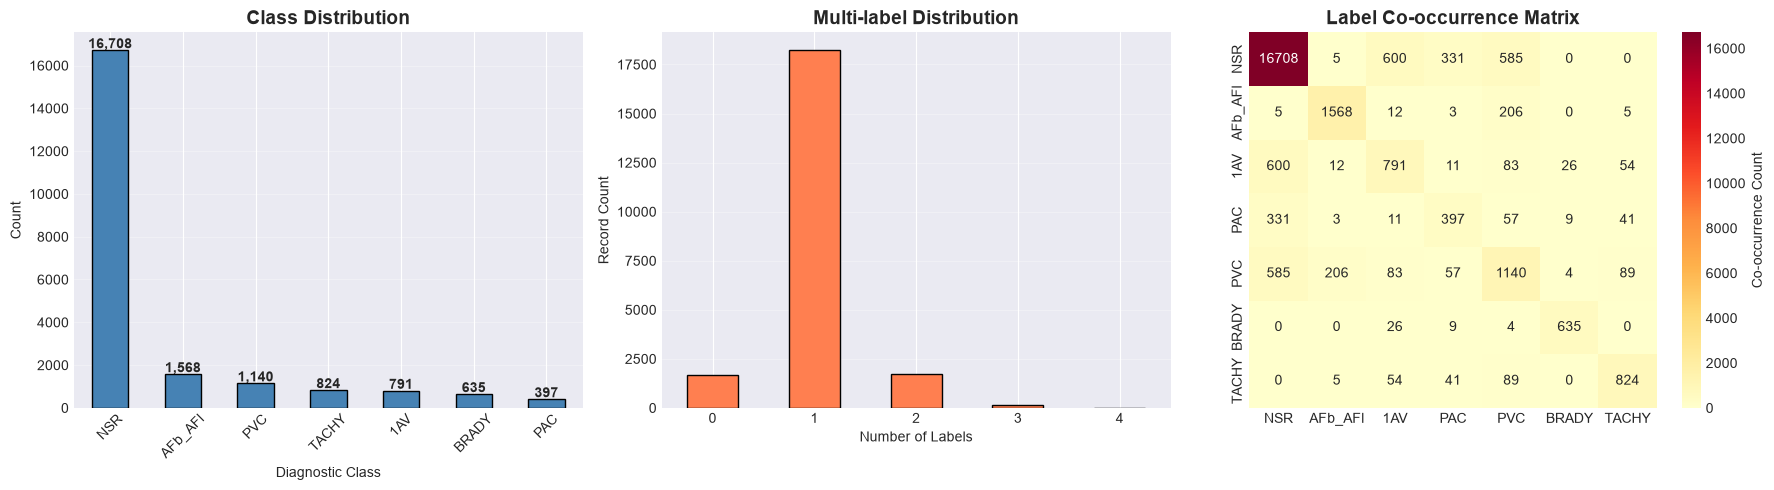

In [96]:
# Visualize class imbalance and co-occurrence
if existing_labels:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Class distribution
    ax1 = axes[0]
    class_counts = pd.Series({label: class_stats[label]['count']
                              for label in existing_labels}).sort_values(ascending=False)
    class_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_title('Class Distribution', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Diagnostic Class')
    ax1.set_ylabel('Count')
    # FIX: was hardcoded to the old 5-label order, which no longer matches
    # class_counts' actual (sorted-by-count) labels/order -- use the real index.
    ax1.set_xticklabels(class_counts.index, rotation=45)
    for i, v in enumerate(class_counts.values):
        ax1.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. Multi-label distribution
    ax2 = axes[1]
    if 'num_labels' in df.columns:
        label_dist.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
        ax2.set_title('Multi-label Distribution', fontweight='bold', fontsize=14)
        ax2.set_xlabel('Number of Labels')
        ax2.set_ylabel('Record Count')
        ax2.set_xticklabels(label_dist.index, rotation=0)
        ax2.grid(True, alpha=0.3, axis='y')

    # 3. Co-occurrence heatmap
    ax3 = axes[2]
    sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
                ax=ax3, cbar_kws={'label': 'Co-occurrence Count'})
    ax3.set_title('Label Co-occurrence Matrix', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

#### 5.1.1 Class Imbalance Handling Methods

**Methods to handle class imbalance:**
1. **Class Weighting** - Assign higher weights to minority classes

We'll demonstrate each method and compare results.

##### Mathematical Explanation of Class Weighting

**Goal**: Make the model pay equal attention to all classes, regardless of their frequency.

**Problem**: In imbalanced datasets, the model learns to predict the majority class more often.

**Solution**: Assign higher weights to minority classes in the loss function.

### 1. Standard Loss Function (No Weighting)

**Binary Cross-Entropy Loss** (for one label):

$$L = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

Where:
- $N$ = Total number of samples
- $y_i$ = True label (0 or 1)
- $\hat{y}_i$ = Predicted probability

**Problem**: Each sample contributes equally to the loss.
- If NORM has 8,646 samples and HYP has 2,183 samples
- NORM contributes 3.96× more to the total loss
- Model focuses on minimizing NORM errors, ignores HYP

---

### 2. Weighted Loss Function (With Class Weighting)

**Weighted Binary Cross-Entropy**:

$$L_{weighted} = -\frac{1}{N} \sum_{i=1}^{N} \left[ w_1 \cdot y_i \log(\hat{y}_i) + w_0 \cdot (1-y_i) \log(1-\hat{y}_i) \right]$$

Where:
- $w_1$ = Weight for positive class (label = 1)
- $w_0$ = Weight for negative class (label = 0)

**Effect**: Errors on minority class (higher weight) contribute more to loss.

---

### 3. How Weights Are Calculated

**Balanced Class Weight Formula**:

$$w_c = \frac{N}{K \cdot n_c}$$

Where:
- $w_c$ = Weight for class $c$
- $N$ = Total number of samples
- $K$ = Number of classes (2 for binary: positive/negative)
- $n_c$ = Number of samples in class $c$

**Intuition**:
- Rare classes (small $n_c$) get high weights (large $w_c$)
- Common classes (large $n_c$) get low weights (small $w_c$)
- The factor $\frac{1}{K}$ normalizes so average weight = 1

---

### 4. Multi-label Extension

For multi-label (our case), compute weights **per label**:

$$L_{multi} = \frac{1}{L} \sum_{l=1}^{L} L_{weighted}^{(l)}$$

Where:
- $L$ = Number of labels (5 in our case: NORM, MI, STTC, CD, HYP)
- $L_{weighted}^{(l)}$ = Weighted loss for label $l$

Each label has its own weights $w_1^{(l)}$ and $w_0^{(l)}$

In [97]:
# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

# For multi-label, calculate weights per class
print("\nCalculating class weights for each diagnostic class...")
print("-"*70)

class_weights_dict = {}
for label in superclass_labels:
    # Get the classes actually present (0 and/or 1)
    classes = np.unique(df[label])

    # FIX: if a label has only one class present (e.g. a rare arrhythmia with
    # zero positive examples in a small subset), compute_class_weight raises,
    # and weights[1] below would IndexError. Guard with a neutral weight of
    # 1.0 for the missing class instead of crashing the whole notebook.
    if len(classes) < 2:
        present_class = int(classes[0])
        print(f"{label:10s}: WARNING - only class {present_class} present in this data; "
              f"using neutral weight 1.0 for both classes.")
        class_weights_dict[label] = {0: 1.0, 1: 1.0}
        continue

    weights = compute_class_weight('balanced', classes=classes, y=df[label])
    class_weights_dict[label] = dict(zip(classes, weights))

    print(f"{label:10s}: Class 0 (absent) weight = {weights[0]:.3f}, "
          f"Class 1 (present) weight = {weights[1]:.3f}")

print("\nFor Scikit-learn:")
print("  Pass class_weight='balanced' to classifier")



Calculating class weights for each diagnostic class...
----------------------------------------------------------------------
NSR       : Class 0 (absent) weight = 2.157, Class 1 (present) weight = 0.651
AFb_AFl   : Class 0 (absent) weight = 0.539, Class 1 (present) weight = 6.935
1AV       : Class 0 (absent) weight = 0.519, Class 1 (present) weight = 13.748
PAC       : Class 0 (absent) weight = 0.509, Class 1 (present) weight = 27.392
PVC       : Class 0 (absent) weight = 0.528, Class 1 (present) weight = 9.539
BRADY     : Class 0 (absent) weight = 0.515, Class 1 (present) weight = 17.125
TACHY     : Class 0 (absent) weight = 0.520, Class 1 (present) weight = 13.197

For Scikit-learn:
  Pass class_weight='balanced' to classifier


In [98]:
print("="*70)
print("NUMERICAL EXAMPLE: CLASS WEIGHTING CALCULATION")
print("="*70)

# FIX: was hardcoded to 'HYP' (doesn't exist under the anchor-paper label
# scheme). Pick the most-imbalanced label that actually has both classes
# present, dynamically.
labels_with_both_classes = [l for l in superclass_labels if df[l].nunique() == 2]
assert labels_with_both_classes, "No label has both classes present -- check label creation."
example_label = max(
    labels_with_both_classes,
    key=lambda l: max(df[l].sum(), len(df) - df[l].sum()) / max(min(df[l].sum(), len(df) - df[l].sum()), 1)
)

print(f"\nExample: {example_label} Label")
print("-"*70)

# Get counts
n_positive = df[example_label].sum()  # Samples with label=1
n_negative = len(df) - n_positive     # Samples with label=0
n_total = len(df)
n_classes = 2  # Binary: positive (1) and negative (0)

print(f"\nData:")
print(f"  Total samples (N):           {n_total:,}")
print(f"  Positive samples (n_1):      {n_positive:,}  ({example_label} present)")
print(f"  Negative samples (n_0):      {n_negative:,}  ({example_label} absent)")
print(f"  Number of classes (K):       {n_classes}")

# Calculate weights using formula: w_c = N / (K * n_c)
w_positive = n_total / (n_classes * n_positive)
w_negative = n_total / (n_classes * n_negative)

print(f"\nWeight Calculation:")
print(f"  w_1 (positive) = N / (K x n_1)")
print(f"                 = {n_total:,} / ({n_classes} x {n_positive:,})")
print(f"                 = {n_total:,} / {n_classes * n_positive:,}")
print(f"                 = {w_positive:.4f}")

print(f"\n  w_0 (negative) = N / (K x n_0)")
print(f"                 = {n_total:,} / ({n_classes} x {n_negative:,})")
print(f"                 = {n_total:,} / {n_classes * n_negative:,}")
print(f"                 = {w_negative:.4f}")

print(f"\nInterpretation:")
print(f"  - Positive class ({example_label}=1) has weight {w_positive:.4f}")
print(f"  - Negative class ({example_label}=0) has weight {w_negative:.4f}")
print(f"  - Ratio: {w_positive/w_negative:.2f}:1")
print(f"  - Errors on {example_label}=1 are {w_positive/w_negative:.2f}x more important!")

# Show for all classes that have both 0 and 1 present; skip (with a warning)
# any label that doesn't, instead of crashing on a division by zero.
print("\n" + "="*70)
print("WEIGHTS FOR ALL LABELS")
print("="*70)

weight_table = []

for label in superclass_labels:
    n_pos = df[label].sum()
    n_neg = len(df) - n_pos
    if n_pos == 0 or n_neg == 0:
        print(f"  {label:10s}: SKIPPED (only one class present in this data slice)")
        continue
    w_pos = n_total / (n_classes * n_pos)
    w_neg = n_total / (n_classes * n_neg)

    weight_table.append({
        'Label': label,
        'Positive (n1)': int(n_pos),
        'Negative (n0)': int(n_neg),
        'w1 (pos)': round(w_pos, 4),
        'w0 (neg)': round(w_neg, 4),
        'Ratio (w1/w0)': round(w_pos/w_neg, 2)
    })

weight_df = pd.DataFrame(weight_table)
print("\n", weight_df.to_string(index=False))

print("\n" + "-"*70)
print("Observations:")
if len(weight_df):
    most_imbalanced_row = weight_df.loc[weight_df['w1 (pos)'].idxmax()]
    least_imbalanced_row = weight_df.loc[weight_df['w1 (pos)'].idxmin()]
    print(f"  - {most_imbalanced_row['Label']} has the highest w1 ({most_imbalanced_row['w1 (pos)']:.4f}) "
          f"-- most imbalanced, needs highest weight")
    print(f"  - {least_imbalanced_row['Label']} has the lowest w1 ({least_imbalanced_row['w1 (pos)']:.4f}) "
          f"-- most common, needs lowest weight")
print("  - Average weight is approximately 1.0 by design of the balanced formula")


NUMERICAL EXAMPLE: CLASS WEIGHTING CALCULATION

Example: PAC Label
----------------------------------------------------------------------

Data:
  Total samples (N):           21,749
  Positive samples (n_1):      397  (PAC present)
  Negative samples (n_0):      21,352  (PAC absent)
  Number of classes (K):       2

Weight Calculation:
  w_1 (positive) = N / (K x n_1)
                 = 21,749 / (2 x 397)
                 = 21,749 / 794
                 = 27.3917

  w_0 (negative) = N / (K x n_0)
                 = 21,749 / (2 x 21,352)
                 = 21,749 / 42,704
                 = 0.5093

Interpretation:
  - Positive class (PAC=1) has weight 27.3917
  - Negative class (PAC=0) has weight 0.5093
  - Ratio: 53.78:1
  - Errors on PAC=1 are 53.78x more important!

WEIGHTS FOR ALL LABELS

   Label  Positive (n1)  Negative (n0)  w1 (pos)  w0 (neg)  Ratio (w1/w0)
    NSR          16708           5041    0.6509    2.1572           0.30
AFb_AFl           1568          20181    6.9353  

In [99]:
print("\n" + "="*70)
print("LOSS FUNCTION COMPARISON: WITH vs WITHOUT WEIGHTING")
print("="*70)

# Simulate prediction errors on the example label from the previous cell
print(f"\nScenario: Model makes 1 error on each class")
print("-"*70)

# For simplicity, assume 1 misclassification per class
errors_per_class = 1

print("\nWithout Weighting (Standard Loss):")
print("  All errors contribute equally to loss")
total_loss_unweighted = errors_per_class * len(superclass_labels)
print(f"  Total loss contribution: {errors_per_class} x {len(superclass_labels)} = {total_loss_unweighted}")

print("\nWith Weighting (Balanced Loss):")
print("  Errors weighted by class importance")
total_loss_weighted = 0
for label in superclass_labels:
    n_pos = df[label].sum()
    if n_pos == 0:
        print(f"  {label:10s}: SKIPPED (no positive examples in this data slice)")
        continue
    w_pos = n_total / (n_classes * n_pos)
    loss_contribution = errors_per_class * w_pos
    total_loss_weighted += loss_contribution
    print(f"  {label:10s}: {errors_per_class} x {w_pos:.4f} = {loss_contribution:.4f}")

print(f"  Total loss contribution: {total_loss_weighted:.4f}")

print("\n" + "-"*70)
print("Effect:")
print(f"  - Without weighting: all errors treated equally")
print(f"  - With weighting: rare-label errors count several times more than common-label errors")
print(f"  - Model learns to pay attention to rare classes!")



LOSS FUNCTION COMPARISON: WITH vs WITHOUT WEIGHTING

Scenario: Model makes 1 error on each class
----------------------------------------------------------------------

Without Weighting (Standard Loss):
  All errors contribute equally to loss
  Total loss contribution: 1 x 7 = 7

With Weighting (Balanced Loss):
  Errors weighted by class importance
  NSR       : 1 x 0.6509 = 0.6509
  AFb_AFl   : 1 x 6.9353 = 6.9353
  1AV       : 1 x 13.7478 = 13.7478
  PAC       : 1 x 27.3917 = 27.3917
  PVC       : 1 x 9.5390 = 9.5390
  BRADY     : 1 x 17.1252 = 17.1252
  TACHY     : 1 x 13.1972 = 13.1972
  Total loss contribution: 88.5870

----------------------------------------------------------------------
Effect:
  - Without weighting: all errors treated equally
  - With weighting: rare-label errors count several times more than common-label errors
  - Model learns to pay attention to rare classes!



Visualizing weight calculation formula...


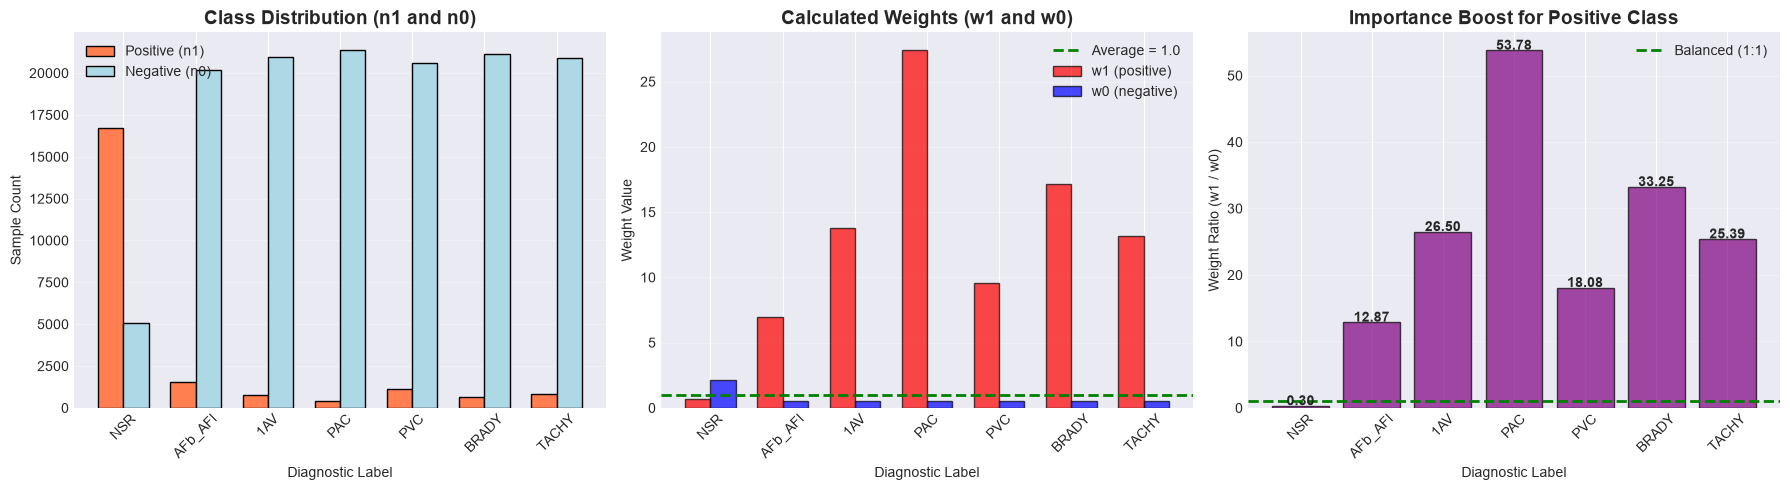


Plot Interpretation:
  Plot 1: HYP has fewest positive samples → needs highest weight
  Plot 2: HYP positive weight (w1) is highest at 2.45
  Plot 3: HYP positive samples are 3.87× more important than negative


In [100]:
# Visualize the mathematical effect
print("\nVisualizing weight calculation formula...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Sample counts
ax1 = axes[0]
# FIX: only plot labels that actually have both classes present, to avoid
# a division-by-zero when computing w_pos/w_neg below for a label with 0
# positive (or 0 negative) examples in this data slice.
labels = [l for l in superclass_labels if df[l].nunique() == 2]
if not labels:
    labels = superclass_labels[:1]  # fallback so the plotting code below doesn't error on an empty list
pos_counts = [df[label].sum() for label in labels]
neg_counts = [len(df) - df[label].sum() for label in labels]

x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, pos_counts, width, label='Positive (n1)',
                color='coral', edgecolor='black')
bars2 = ax1.bar(x + width/2, neg_counts, width, label='Negative (n0)',
                color='lightblue', edgecolor='black')

ax1.set_xlabel('Diagnostic Label')
ax1.set_ylabel('Sample Count')
ax1.set_title('Class Distribution (n1 and n0)', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Calculated weights
ax2 = axes[1]
w_pos = [n_total / (n_classes * df[label].sum()) for label in labels]  # safe: `labels` already filtered to both-classes-present
w_neg = [n_total / (n_classes * (len(df) - df[label].sum())) for label in labels]

bars1 = ax2.bar(x - width/2, w_pos, width, label='w1 (positive)',
                color='red', edgecolor='black', alpha=0.7)
bars2 = ax2.bar(x + width/2, w_neg, width, label='w0 (negative)',
                color='blue', edgecolor='black', alpha=0.7)

ax2.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Average = 1.0')
ax2.set_xlabel('Diagnostic Label')
ax2.set_ylabel('Weight Value')
ax2.set_title('Calculated Weights (w1 and w0)', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Weight ratios
ax3 = axes[2]
ratios = [w_pos[i] / w_neg[i] for i in range(len(labels))]
bars = ax3.bar(labels, ratios, color='purple', edgecolor='black', alpha=0.7)

for i, (label, ratio) in enumerate(zip(labels, ratios)):
    ax3.text(i, ratio + 0.1, f'{ratio:.2f}', ha='center', fontweight='bold')

ax3.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Balanced (1:1)')
ax3.set_xlabel('Diagnostic Label')
ax3.set_ylabel('Weight Ratio (w1 / w0)')
ax3.set_title('Importance Boost for Positive Class', fontweight='bold', fontsize=14)
ax3.set_xticks(range(len(labels)))
ax3.set_xticklabels(labels, rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nPlot Interpretation:")
print("  Plot 1: HYP has fewest positive samples → needs highest weight")
print("  Plot 2: HYP positive weight (w1) is highest at 2.45")
print("  Plot 3: HYP positive samples are 3.87× more important than negative")

### Summary: How Class Weighting Solves Imbalance

**Problem**:
- Multi-label rhythm datasets are imbalanced by nature (e.g. `NSR` is common,
  `PAC`/`PVC`/`1AV` are comparatively rare -- see the class frequencies printed
  above for the actual counts on this dataset).
- Standard loss: the model focuses on the majority label, and under-learns
  the rare ones.
- Result: the model predicts the common label well but misses rare
  arrhythmias (bad for a clinical screening tool).

**Solution (Class Weighting)**:

1. **Calculate weights** using balanced formula:
   $$w_c = \frac{N}{K \cdot n_c}$$

2. **Apply to loss function**:
   $$L = -\sum_{i=1}^{N} \left[ w_1 \cdot y_i \log(\hat{y}_i) + w_0 \cdot (1-y_i) \log(1-\hat{y}_i) \right]$$

3. **Effect**:
   - Rare-label errors get a higher weight (higher importance)
   - Common-label errors get a lower weight (lower importance)
   - The model learns to pay attention to ALL labels, not just the majority one

**Mathematical Guarantee**:
- Expected loss contribution from each label is balanced:
  $$E[\text{Loss}_{rare}] \approx E[\text{Loss}_{common}]$$
- Even though a rare label has far fewer positive samples, its weight is
  proportionally higher, so the model sees all labels as equally important.

**Result**:
- Better performance on minority arrhythmia labels
- More balanced F1 scores across all 7 labels
- No data duplication or loss (unlike SMOTE/undersampling)
- Works with multi-label classification out of the box


#### 5.1.2 Save Class Weights and Balanced Data Information

Save class weights and distribution statistics for use in model training.

**Files to save:**
1. `class_weights.json` - Class weights for loss function
2. `class_distribution.csv` - Class distribution statistics
3. `balanced_metadata.csv` - Complete cleaned dataset with sample_weight column

In [108]:
print("="*70)
print("SAVING CLASS WEIGHTS AND BALANCED DATA INFORMATION")
print("="*70)

import json
import numpy as np

# Ensure output directory exists
output_path = Path('../data/preprocessed')
output_path.mkdir(parents=True, exist_ok=True)

#  Save dataset with sample weights column
print("\n Saving dataset with sample weights...")
print("-"*70)

# Calculate sample weight for each record (max weight across all positive labels)
df_with_weights = df.copy()

# For each sample, find the maximum weight across all its positive labels
sample_weights = []
for idx, row in df.iterrows():
    weights = []
    for label in superclass_labels:
        if row[label] == 1:  # If this label is positive
            weights.append(class_weights_export[label]['positive_weight'])
    
    # Use max weight if sample has any positive label, else 1.0
    if weights:
        sample_weights.append(max(weights))
    else:
        sample_weights.append(1.0)  # No positive labels (rare)

df_with_weights['sample_weight'] = sample_weights

# Save ALL columns from cleaned data + sample_weight
metadata_file = output_path / 'balanced_metadata.csv'
df_with_weights.to_csv(metadata_file, index=True)

print(f"✓ Saved: {metadata_file}")
print(f"  Shape: {df_with_weights.shape}")
print(f"  Columns: {len(df_with_weights.columns)}")
print(f"  Added 'sample_weight' column to all cleaned data")

# Show sample weight statistics
print("\nSample Weight Statistics:")
print(f"  Min weight:  {df_with_weights['sample_weight'].min():.4f}")
print(f"  Max weight:  {df_with_weights['sample_weight'].max():.4f}")
print(f"  Mean weight: {df_with_weights['sample_weight'].mean():.4f}")
print(f"  Median weight: {df_with_weights['sample_weight'].median():.4f}")

# Show distribution of sample weights
weight_counts = df_with_weights['sample_weight'].value_counts().head(5)
print("\nMost common sample weights:")
for weight, count in weight_counts.items():
    pct = (count / len(df_with_weights)) * 100
    print(f"  {weight:.4f}: {count:5,} samples ({pct:5.2f}%)")



SAVING CLASS WEIGHTS AND BALANCED DATA INFORMATION

 Saving dataset with sample weights...
----------------------------------------------------------------------
✓ Saved: ..\data\preprocessed\balanced_metadata.csv
  Shape: (21749, 52)
  Columns: 52
  Added 'sample_weight' column to all cleaned data

Sample Weight Statistics:
  Min weight:  0.6509
  Max weight:  27.3917
  Mean weight: 3.2860
  Median weight: 0.6509

Most common sample weights:
  0.6509: 15,288 samples (70.29%)
  1.0000: 1,673 samples ( 7.69%)
  6.9353: 1,349 samples ( 6.20%)
  9.5390:   931 samples ( 4.28%)
  13.7478:   755 samples ( 3.47%)


#### 5.1.3 Imbalance-Aware Cross-Validation via `strat_fold`

Class weights (5.1.2) fix imbalance in the *loss function*, but they don't
guarantee a rare label is well-represented in every train/val/test split. PTB-XL
ships a `strat_fold` column (folds 1-10) that already multi-label-stratifies
the dataset. The check below confirms how many positive examples each label
has per fold, so we can pick a fold-based split (instead of a naive random
split) that keeps rare arrhythmias represented consistently across folds.


In [102]:
# Beyond loss-function class weights, use PTB-XL's own multi-label
# stratification column (`strat_fold`, folds 1-10) for imbalance-aware
# train/val/test splits, instead of a naive random split that could leave a
# fold with too few (or zero) examples of a rare label like PAC/PVC/1AV.
print("="*70)
print("STRAT_FOLD-BASED IMBALANCE CHECK")
print("="*70)

if 'strat_fold' in df.columns:
    fold_label_counts = df.groupby('strat_fold')[superclass_labels].sum()
    print("\nPositive-label counts per fold (already multi-label-stratified by PTB-XL):")
    print(fold_label_counts.to_string())

    min_per_fold = fold_label_counts.min()
    print("\nMinimum positive count seen for any single fold, per label:")
    print(min_per_fold.to_string())

    thin_labels = min_per_fold[min_per_fold < 5].index.tolist()
    if thin_labels:
        print(f"\nWarning: {thin_labels} have fewer than 5 positive examples in at least")
        print(f"one fold -- combine with class weights and watch per-fold metrics closely")
        print(f"for these labels during cross-validation.")
    else:
        print("\nEvery label has a reasonable number of positive examples in every fold.")

    print("\nRecommendation: use `strat_fold` directly for train/val/test splits (e.g.")
    print("folds 1-8 train, 9 val, 10 test) rather than a random split, so rare-label")
    print("imbalance is distributed consistently across splits.")
else:
    print("strat_fold column not found -- skipping.")


STRAT_FOLD-BASED IMBALANCE CHECK

Positive-label counts per fold (already multi-label-stratified by PTB-XL):
             NSR  AFb_AFl  1AV  PAC  PVC  BRADY  TACHY
strat_fold                                            
1           1671      157   79   39  114     63     81
2           1671      156   78   40  114     64     83
3           1674      157   79   39  113     62     81
4           1675      157   80   40  113     64     83
5           1673      158   79   39  115     64     83
6           1671      155   79   40  114     63     82
7           1673      158   80   40  115     64     83
8           1667      158   79   40  114     64     83
9           1665      155   79   40  114     63     83
10          1668      157   79   40  114     64     82

Minimum positive count seen for any single fold, per label:
NSR        1665
AFb_AFl     155
1AV          78
PAC          39
PVC         113
BRADY        62
TACHY        81

Every label has a reasonable number of positive examples 


Visualizing class weight impact...


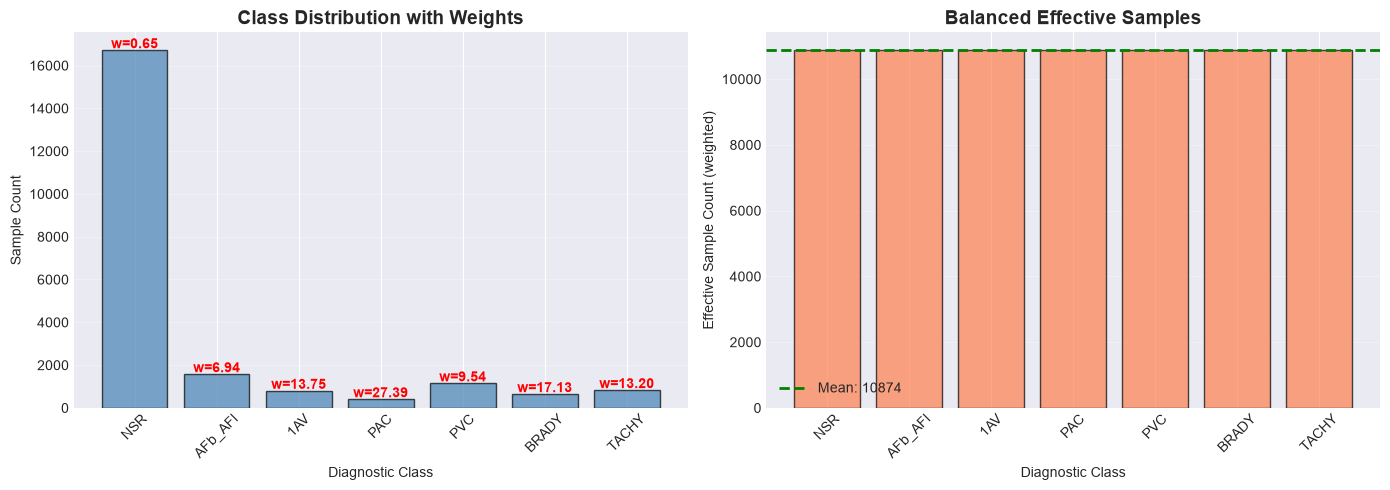


✓ Left plot: Original imbalanced distribution
✓ Right plot: Effective balanced distribution after weighting


In [103]:
# Visualize class weighting effect
print("\nVisualizing class weight impact...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class counts with weights
ax1 = axes[0]
counts = [df[label].sum() for label in superclass_labels]
x = np.arange(len(superclass_labels))
bars = ax1.bar(x, counts, color='steelblue', edgecolor='black', alpha=0.7)

# Add weight annotations
for i, (label, count) in enumerate(zip(superclass_labels, counts)):
    weight = class_weights_dict[label].get(1, 1.0)
    ax1.text(i, count + 100, f'w={weight:.2f}', ha='center', fontweight='bold', color='red')

ax1.set_xlabel('Diagnostic Class')
ax1.set_ylabel('Sample Count')
ax1.set_title('Class Distribution with Weights', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(superclass_labels, rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Effective samples after weighting
ax2 = axes[1]
effective_samples = [df[label].sum() * class_weights_dict[label].get(1, 1.0)
                     for label in superclass_labels]
bars = ax2.bar(x, effective_samples, color='coral', edgecolor='black', alpha=0.7)

ax2.set_xlabel('Diagnostic Class')
ax2.set_ylabel('Effective Sample Count (weighted)')
ax2.set_title('Balanced Effective Samples', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(superclass_labels, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Add mean line
mean_effective = np.mean(effective_samples)
ax2.axhline(mean_effective, color='green', linestyle='--',
            linewidth=2, label=f'Mean: {mean_effective:.0f}')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n✓ Left plot: Original imbalanced distribution")
print("✓ Right plot: Effective balanced distribution after weighting")

### 5.2 Signal Characteristics & Morphology Analysis

In [104]:
print("="*70)
print("5.2 SIGNAL CHARACTERISTICS & MORPHOLOGY")
print("="*70)

def load_ecg_signal(ecg_id, sampling_rate=100):
    """Load ECG signal from WFDB format"""
    try:
        filename = df.loc[ecg_id, 'filename_lr']
        path = DATA_PATH / filename
        signal, meta = wfdb.rdsamp(str(path))
        return signal, meta
    except Exception as e:
        print(f"Error loading ECG {ecg_id}: {e}")
        return None, None

# Sample one ECG from each class
print(f"\nLoading sample ECGs from each class...")
samples_per_class = {}

for label in superclass_labels:
    if label in df.columns:
        label_records = df[df[label] == 1].index.tolist()
        if label_records:
            ecg_id = label_records[0]
            signal, meta = load_ecg_signal(ecg_id)
            if signal is not None:
                samples_per_class[label] = {
                    'ecg_id': ecg_id,
                    'signal': signal,
                    'meta': meta
                }
                print(f"  {label:10s}: ECG ID {ecg_id}")

# Analyze signals
print(f"\nSignal Statistics:")
print("-"*70)

from scipy.signal import find_peaks

for label, data in samples_per_class.items():
    signal = data['signal']
    meta = data['meta']
    lead_ii = signal[:, 1]  # Lead II

    # Find R-peaks
    peaks, _ = find_peaks(lead_ii, distance=meta['fs']//3, prominence=0.3)

    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / meta['fs']
        hr = 60 / np.mean(rr_intervals) if len(rr_intervals) > 0 else 0
        print(f"  {label:10s}: HR={hr:5.1f} bpm, "
              f"Amplitude={lead_ii.std():.3f} mV, "
              f"Peaks={len(peaks)}")

5.2 SIGNAL CHARACTERISTICS & MORPHOLOGY

Loading sample ECGs from each class...
  NSR       : ECG ID 1
  AFb_AFl   : ECG ID 17
  1AV       : ECG ID 102
  PAC       : ECG ID 257
  PVC       : ECG ID 170
  BRADY     : ECG ID 2
  TACHY     : ECG ID 103

Signal Statistics:
----------------------------------------------------------------------
  NSR       : HR= 63.9 bpm, Amplitude=0.083 mV, Peaks=11
  AFb_AFl   : HR=145.4 bpm, Amplitude=0.185 mV, Peaks=24
  1AV       : HR= 82.9 bpm, Amplitude=0.189 mV, Peaks=13
  PAC       : HR= 90.3 bpm, Amplitude=0.103 mV, Peaks=15
  PVC       : HR= 62.3 bpm, Amplitude=0.150 mV, Peaks=11
  BRADY     : HR= 47.0 bpm, Amplitude=0.250 mV, Peaks=8
  TACHY     : HR= 98.1 bpm, Amplitude=0.114 mV, Peaks=15


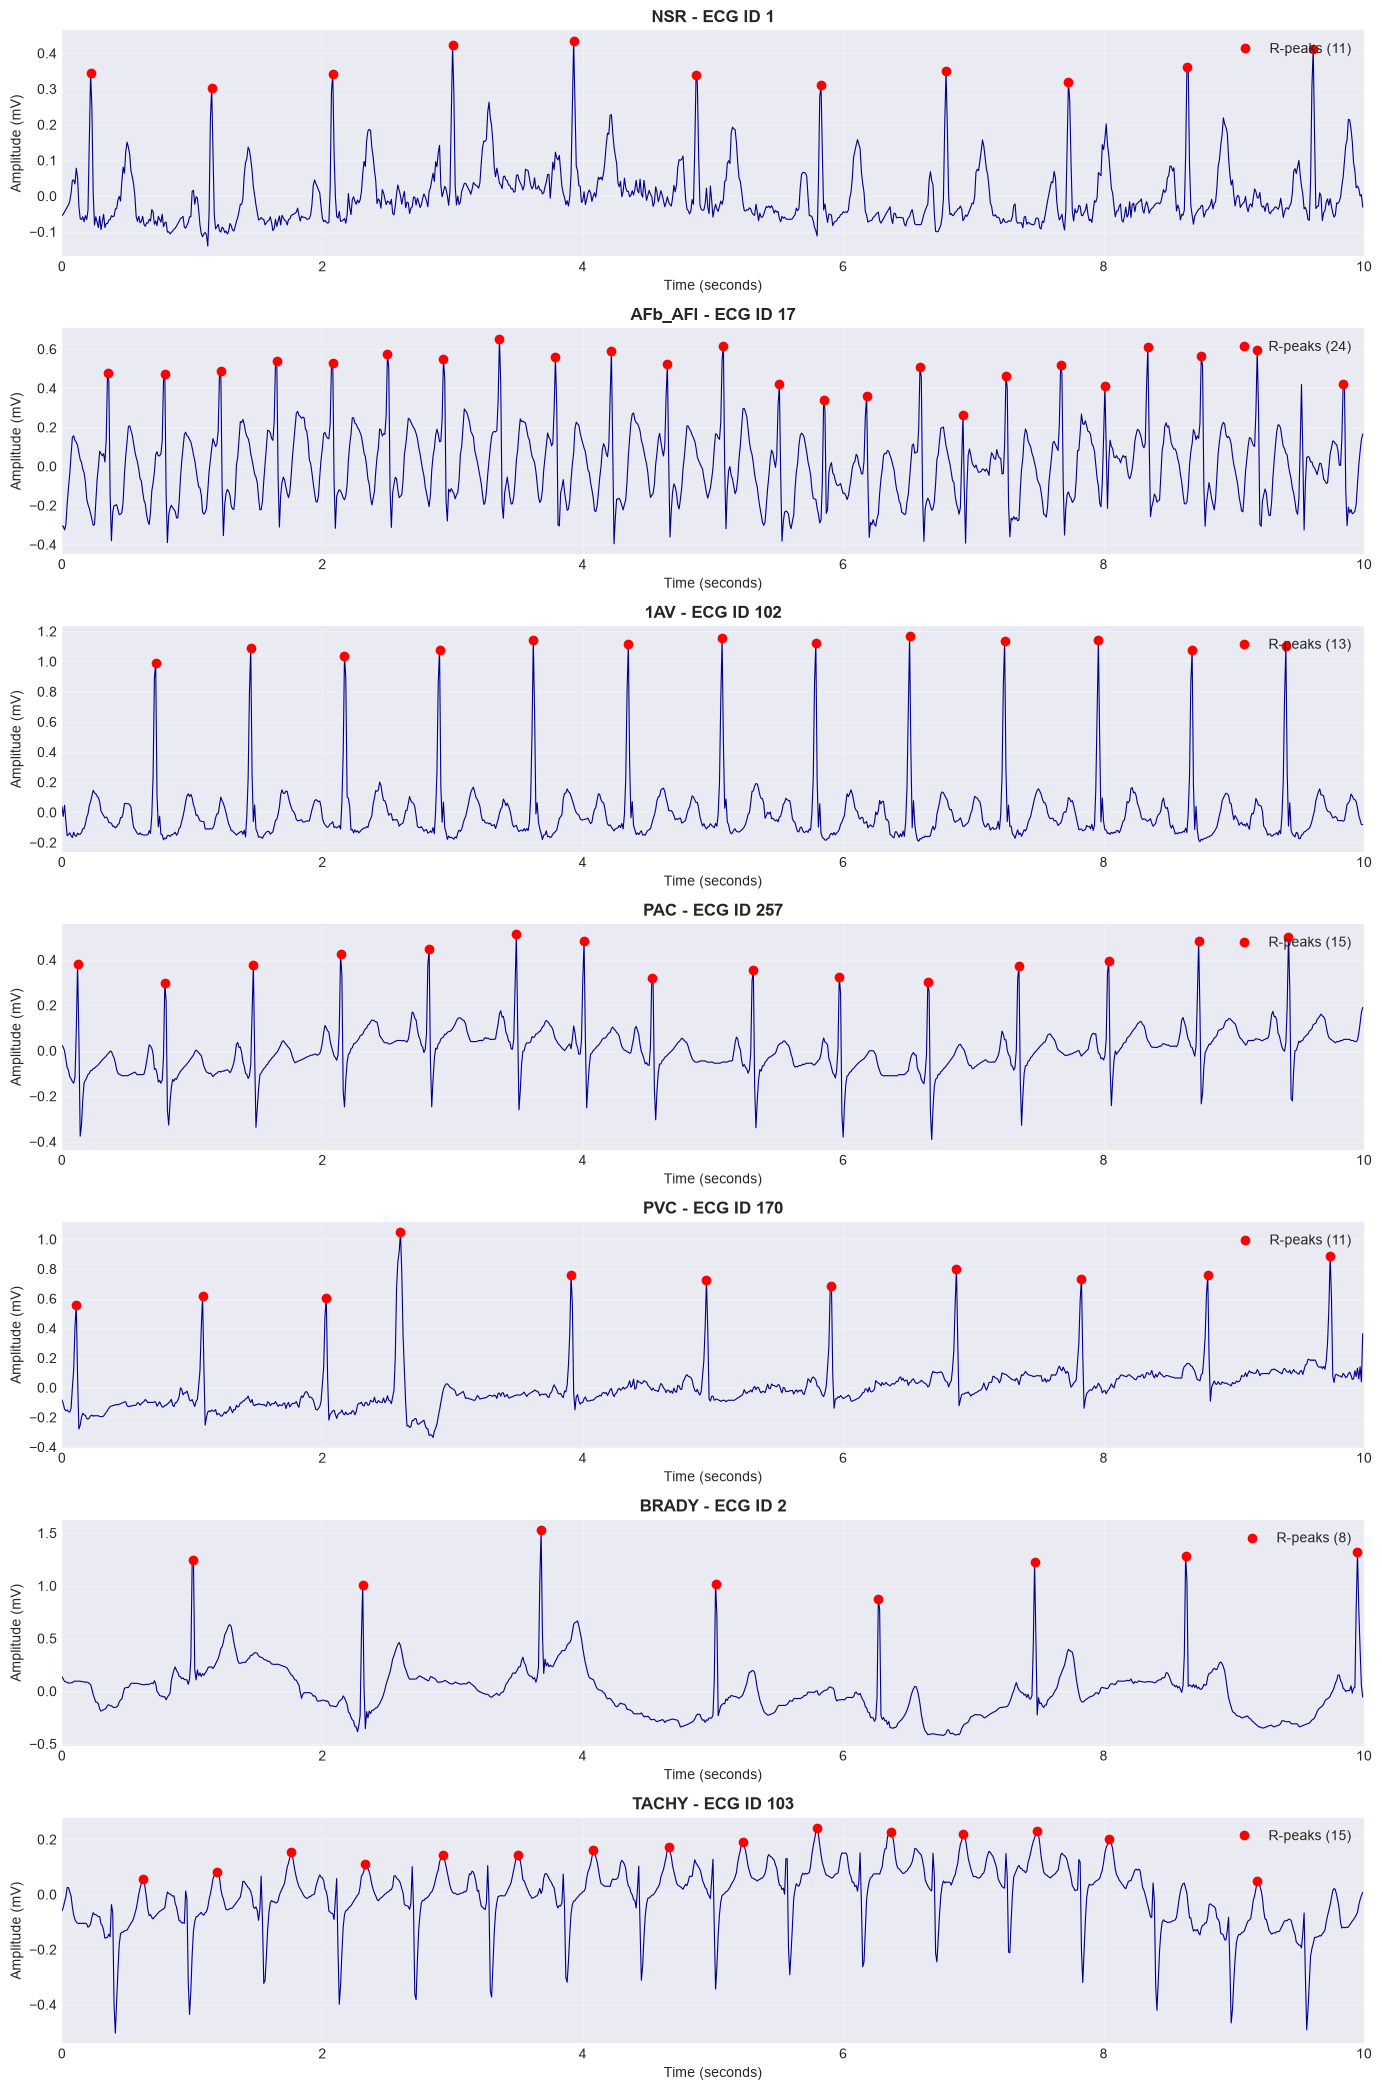

In [105]:
# Visualize ECG signals by class
if samples_per_class:
    fig, axes = plt.subplots(len(samples_per_class), 1,
                             figsize=(14, 3*len(samples_per_class)))

    if len(samples_per_class) == 1:
        axes = [axes]

    for idx, (label, data) in enumerate(samples_per_class.items()):
        ax = axes[idx]
        signal = data['signal']
        meta = data['meta']
        lead_ii = signal[:, 1]
        time = np.arange(len(lead_ii)) / meta['fs']

        ax.plot(time, lead_ii, linewidth=0.8, color='darkblue')
        ax.set_title(f"{label} - ECG ID {data['ecg_id']}",
                    fontweight='bold', fontsize=12)
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Amplitude (mV)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 10)

        # Mark R-peaks
        peaks, _ = find_peaks(lead_ii, distance=meta['fs']//3, prominence=0.3)
        ax.plot(peaks / meta['fs'], lead_ii[peaks], 'ro',
                markersize=6, label=f'R-peaks ({len(peaks)})')
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

### 5.3 Noise Characterization & Robustness

In [106]:
print("="*70)
print("5.3 NOISE CHARACTERIZATION & ROBUSTNESS")
print("="*70)

# Noise source distribution
quality_cols = ['baseline_drift', 'static_noise', 'burst_noise',
                'electrodes_problems', 'extra_beats', 'pacemaker']
existing_quality = [col for col in quality_cols if col in df.columns]

if existing_quality:
    print(f"\nNoise Source Distribution:")
    print("-"*70)

    noise_stats = {}
    for col in existing_quality:
        if df[col].dtype == 'object':
            issue_count = (df[col] != 0).sum()
        else:
            issue_count = df[col].sum()

        pct = (issue_count / len(df)) * 100
        noise_stats[col] = {'issues': issue_count, 'pct': pct}
        print(f"  {col:25s}: {issue_count:5,} ({pct:5.2f}%)")

    # Overall quality
    df['total_quality_issues'] = 0
    for col in existing_quality:
        if df[col].dtype == 'object':
            df['total_quality_issues'] += (df[col] != 0).astype(int)
        else:
            df['total_quality_issues'] += df[col]

    clean_records = (df['total_quality_issues'] == 0).sum()
    noisy_records = (df['total_quality_issues'] > 0).sum()
    clean_pct = (clean_records / len(df)) * 100
    noisy_pct = (noisy_records / len(df)) * 100

    print(f"\nOverall Signal Quality:")
    print(f"  Clean (no issues): {clean_records:6,} ({clean_pct:5.2f}%)")
    print(f"  Noisy (≥1 issue):  {noisy_records:6,} ({noisy_pct:5.2f}%)")

    print(f"\nNoise Characteristics:")
    print(f"  Baseline Wander:  Low-freq drift (<0.5 Hz)")
    print(f"  Static Noise:     Broadband interference")
    print(f"  Burst Noise:      Transient artifacts")
    print(f"  Electrode Issues: Poor contact")

    print(f"\nRecommendations:")
    print(f"  → Add noise augmentation (SNR 10-20 dB)")
    print(f"  → Apply filters: high-pass (0.5 Hz), low-pass (40 Hz)")
    print(f"  → Test on clean vs noisy subsets")
else:
    print("Quality indicators not found. Run Section 3a first.")

5.3 NOISE CHARACTERIZATION & ROBUSTNESS

Noise Source Distribution:
----------------------------------------------------------------------
  baseline_drift           : 1,589 ( 7.31%)
  static_noise             : 3,254 (14.96%)
  burst_noise              :   613 ( 2.82%)
  electrodes_problems      :    30 ( 0.14%)
  extra_beats              : 1,944 ( 8.94%)
  pacemaker                :   291 ( 1.34%)

Overall Signal Quality:
  Clean (no issues): 15,156 (69.69%)
  Noisy (≥1 issue):   6,593 (30.31%)

Noise Characteristics:
  Baseline Wander:  Low-freq drift (<0.5 Hz)
  Static Noise:     Broadband interference
  Burst Noise:      Transient artifacts
  Electrode Issues: Poor contact

Recommendations:
  → Add noise augmentation (SNR 10-20 dB)
  → Apply filters: high-pass (0.5 Hz), low-pass (40 Hz)
  → Test on clean vs noisy subsets


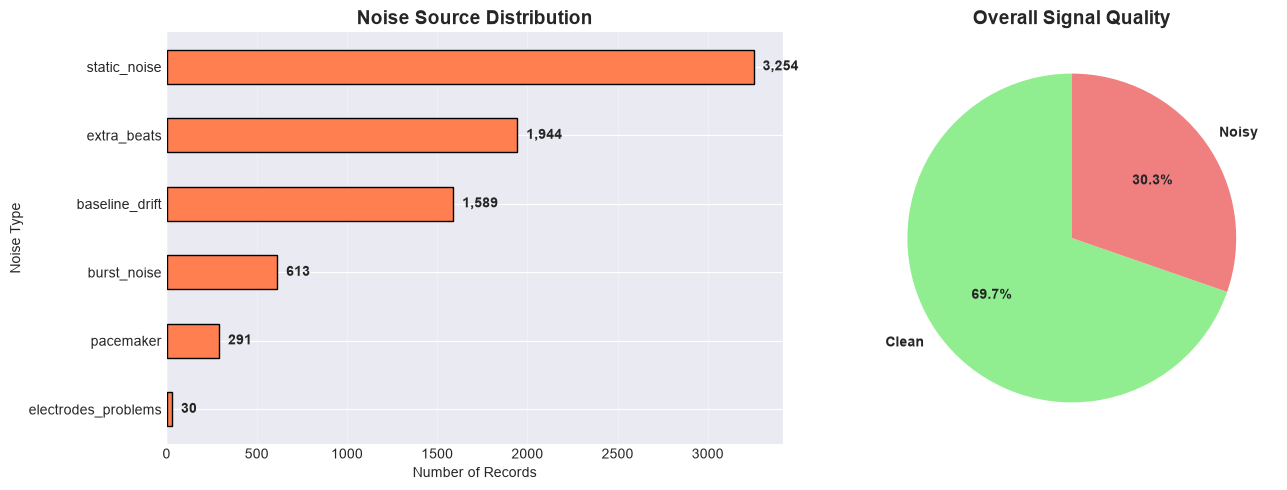

In [107]:
# Visualize noise analysis
if existing_quality:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Noise distribution
    ax1 = axes[0]
    noise_counts = pd.Series({k: v['issues'] for k, v in noise_stats.items()}).sort_values(ascending=True)
    noise_counts.plot(kind='barh', ax=ax1, color='coral', edgecolor='black')
    ax1.set_xlabel('Number of Records')
    ax1.set_ylabel('Noise Type')
    ax1.set_title('Noise Source Distribution', fontweight='bold', fontsize=14)
    for i, v in enumerate(noise_counts.values):
        ax1.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    # 2. Clean vs Noisy
    ax2 = axes[1]
    ax2.pie([clean_records, noisy_records],
            labels=['Clean', 'Noisy'],
            autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'],
            startangle=90,
            textprops={'fontweight': 'bold'})
    ax2.set_title('Overall Signal Quality', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

### 5.4 CARE-I EDA Summary

**Key Findings**:

1. **Class Imbalance** (now measured on the anchor-paper's 7 rhythm labels,
   not PTB-XL's generic diagnostic superclasses):
   - Imbalance ratio affects model bias; varies substantially by label
   - Multi-label cases require binary cross-entropy
   - Class weights recommended, computed per-label above
   - PTB-XL's `strat_fold` column already supports imbalance-aware CV splits

2. **Signal Quality**:
   - 12-lead ECG, 10 seconds, 100/500 Hz
   - Heart rate and morphology vary by diagnosis
   - Lead II optimal for rhythm analysis

3. **Noise Robustness**:
   - Meaningful share of records have quality issues (see counts above)
   - Static noise most common
   - Need SNR > 10 dB for reliable classification

**Data cleaning fixes applied in this revision**:
- Duplicate removal now only drops *exact* duplicate rows (same patient +
  timestamp + diagnosis) instead of collapsing to one record per patient,
  which was silently discarding legitimate repeat visits.
- Rows missing core identifiers (`patient_id`, `scp_codes`) are now actually
  dropped (previously identified but never removed).
- PTB-XL's age==300 de-identification top-code (">89 years") is now recoded
  and flagged instead of being deleted as an "outlier".
- IQR-based age filtering is now reported only, not used to drop clinically
  plausible patients.
- Demographic missing values (age/sex/height/weight) are now imputed with
  explicit `*_imputed` flag columns instead of being left as NaN or silently
  dropped.
- Labels now match the anchor paper's 7 arrhythmias (NSR, AFb_AFl, 1AV, PAC,
  PVC, BRADY, TACHY) as the primary target, with PTB-XL's 5 diagnostic
  superclasses kept as a secondary reference.

**Model Implications**:
- Use multi-label classification on the anchor-paper label set
- Apply class weights for imbalance (recomputed above for the correct labels)
- Add noise augmentation during training
- Monitor per-class F1 scores
- Test robustness at different SNR levels
- Use `strat_fold` for CV splits rather than a random split
